# Exploração de Dados — Abrigo Lambeijos

Análise exploratória dos datasets usados no módulo de recomendação de ML:
- `datasets/raw/pets.csv` — catálogo sintético de animais.
- `datasets/raw/compatibility_dataset.csv` — pares adotante × pet com o rótulo `compatibility`.

Kernel: selecione **Abrigo Lambeijos ML** (venv de `apps/ml/.venv`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Permite importar o pacote `src` a partir do notebook (que vive em apps/ml/notebooks)
sys.path.append(str(Path.cwd().parent))

from src.data.loader import load_compatibility_dataset, load_pets

pets = load_pets()
compatibility = load_compatibility_dataset()

print(f"pets: {pets.shape}")
print(f"compatibility_dataset: {compatibility.shape}")

pets: (300, 22)
compatibility_dataset: (750, 23)


## `pets.csv` — visão geral

In [2]:
pets.info()
pets.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      300 non-null    int64  
 1   name                    300 non-null    str    
 2   species                 300 non-null    str    
 3   age                     300 non-null    float64
 4   size                    300 non-null    str    
 5   type                    300 non-null    str    
 6   breed                   300 non-null    str    
 7   gender                  300 non-null    str    
 8   location                300 non-null    str    
 9   energy_level            300 non-null    str    
 10  temperament             300 non-null    str    
 11  sociability             300 non-null    str    
 12  children_compatibility  300 non-null    bool   
 13  dogs_compatibility      300 non-null    bool   
 14  cats_compatibility      300 non-null    bool   
 15  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,300.0,NaN,NaN,NaN,150.5,86.746758,1.0,75.75,150.5,225.25,300.0
name,300,300,Pet1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
species,300,2,Cat,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,300.0,NaN,NaN,NaN,6.811667,3.975666,0.4,3.3,6.8,10.5,14.0
size,300,3,Small,205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,300,2,Feline,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
breed,300,11,Angorá,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,300,2,Male,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,300,4,"Curitiba, PR",80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy_level,300,3,High,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Qualidade dos dados: nulos, duplicidades e cardinalidade das categóricas
nulls = pets.isna().sum()
nulls = nulls[nulls > 0]
print("Valores nulos por coluna:")
print(nulls if not nulls.empty else "nenhum")
print(f"\nLinhas duplicadas (por id): {pets['id'].duplicated().sum()}")

Valores nulos por coluna:
nenhum

Linhas duplicadas (por id): 0


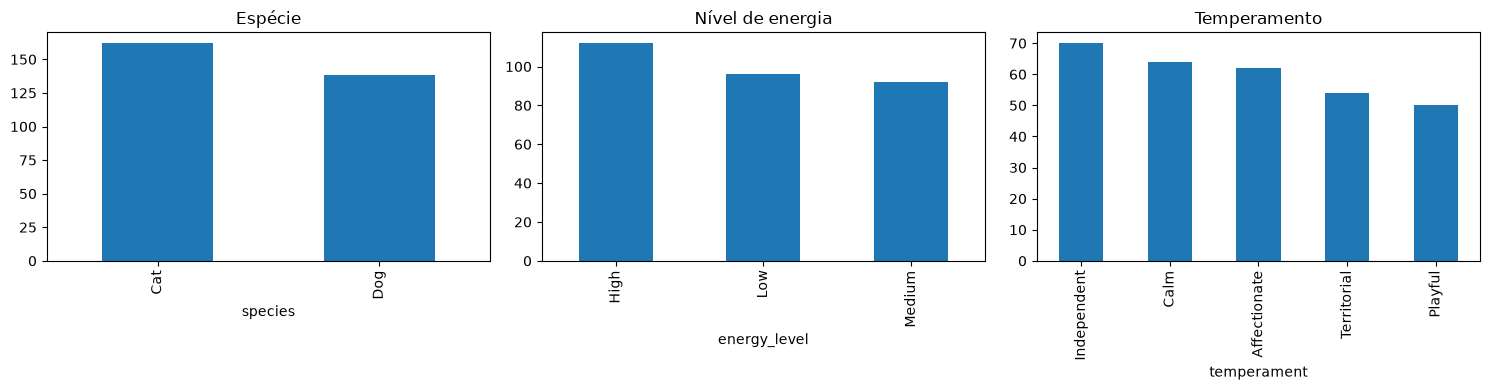

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pets["species"].value_counts().plot(kind="bar", ax=axes[0], title="Espécie")
pets["energy_level"].value_counts().plot(kind="bar", ax=axes[1], title="Nível de energia")
pets["temperament"].value_counts().plot(kind="bar", ax=axes[2], title="Temperamento")
plt.tight_layout()
plt.show()

## `compatibility_dataset.csv` — visão geral e balanceamento de classes

O rótulo `compatibility` é gerado por uma regra determinística (ver
`src/data/generate_datasets.py::_compatibility_score`), não por dados reais de
adoção. Trate como uma heurística de partida ao interpretar os resultados.

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   adopter_id              750 non-null    int64  
 1   pet_id                  750 non-null    int64  
 2   home_type               750 non-null    str    
 3   has_yard                750 non-null    bool   
 4   has_children            750 non-null    bool   
 5   children_age_group      320 non-null    str    
 6   has_other_pets          750 non-null    bool   
 7   other_pets_type         255 non-null    str    
 8   dog_experience          750 non-null    str    
 9   available_time          750 non-null    str    
 10  activity_level          750 non-null    str    
 11  preferred_size          750 non-null    str    
 12  preferred_age           750 non-null    str    
 13  pet_age                 750 non-null    float64
 14  pet_energy_level        750 non-null    str    
 15  

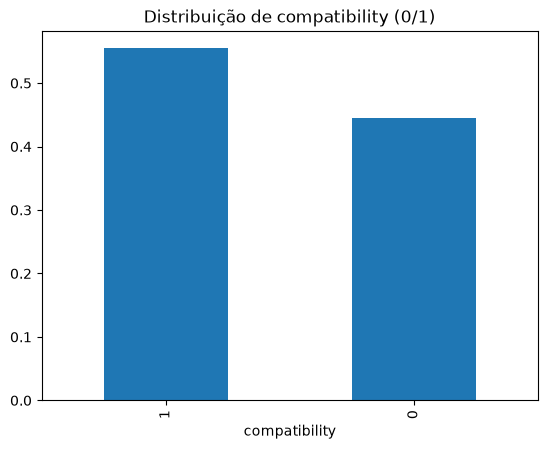

In [6]:
compatibility.info()
class_balance = compatibility["compatibility"].value_counts(normalize=True)
print("\nBalanceamento de classes (compatibility):")
print(class_balance)
class_balance.plot(kind="bar", title="Distribuição de compatibility (0/1)")
plt.show()